In [1]:
import time
import torch
import os
import IPython.display as display

if not hasattr(display, "set_matplotlib_formats"):
    # no-op fallback (or you can force retina/png instead)
    def set_matplotlib_formats(*args, **kwargs):
        return None
    display.set_matplotlib_formats = set_matplotlib_formats

from d2l.torch import Animator

from net import Net
from utils import load_val_dataset
from faco import MFACO_CVRP

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
PRETRAINED_DIR = PROJECT_ROOT / "../pretrained"

# Optional wandb logging (lazy import to avoid hangs at import-time)
USE_WANDB = True
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "claco")
WANDB_ENTITY = os.environ.get("WANDB_ENTITY") or None
WANDB_MODE = os.environ.get("WANDB_MODE", "online")  # set to "offline" to avoid network
wandb = None

def _wandb_init(config: dict, name: str | None = None):
    """Init a fresh wandb run for each train() call.

    In notebooks it's common to re-run the train cell; reusing the same wandb run
    causes non-monotonic step warnings when we log with an explicit `step=`.
    """
    global wandb, USE_WANDB
    if not USE_WANDB:
        return None
    if wandb is None:
        try:
            import wandb as _wandb
            wandb = _wandb
        except Exception as e:
            USE_WANDB = False
            print("wandb disabled (import failed):", e)
            return None
    if wandb.run is not None:
        # Start a new run to avoid step going backwards on re-runs.
        try:
            wandb.finish()
        except Exception:
            pass
    return wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        config=config,
        name=name,
        mode=WANDB_MODE,
    )

torch.manual_seed(1234)

lr = 1e-4
H=10
mini_H=10
rho = 0.5
min_new_edges = 16
disable_heuristic = True
use_local_search = True
smooth_mmas = True
extend_ls = True
normalize_heuristic = True
no_logit_net = False
no_dynamic_feats = False
k_sparse = 32
n_ants = 100
steps_per_epoch = 32
epochs = 10

device = 'cuda:0'

# Import your compiled extension (needed for get_max_threads print below)
try:
    import faco_cvrp
except Exception as e:
    faco_cvrp = None
    print("Warning: could not import faco_cvrp:", e)

if faco_cvrp is not None:
    print("faco_cvrp imported. OpenMP max threads:", faco_cvrp.get_max_threads())

/home/shora/Research/old/NGFACO/data
faco_cvrp imported. OpenMP max threads: 10


In [2]:
# Import training logic from train.py (keep notebook focused on experiments/plots)
from types import SimpleNamespace
import train as train_mod
from tqdm.notebook import tqdm as notebook_tqdm
from functools import partial

# Patch the tqdm symbol used inside train.py
train_mod.tqdm = partial(notebook_tqdm, disable=True)


# Re-export helpers if you still want to inspect/DEBUG them in notebook
_popcount_i64 = train_mod._popcount_i64
replay_logp_from_cpp_batch_trace = train_mod.replay_logp_from_cpp_batch_trace
train_instance = train_mod.train_instance
train_epoch_core = train_mod.train_epoch
validation_core = train_mod.validation


def _make_args(n_node, k_sparse, n_ants, steps_per_epoch, *, H, mini_H, device,
              rho=0.1, min_new_edges=8,
              disable_heuristic=True,
              use_local_search=True,
              smooth_mmas=False,
              extend_ls=False,
              normalized_heuristic=False,
              debug=False,
              use_wandb=False,
              no_logit_net=False,
              baseline='none', baseline_runs=1, baseline_time_limit=10.0):
    """Create a train.py-compatible args namespace from notebook globals."""
    return SimpleNamespace(
        # problem / graph
        n_node=int(n_node),
        k_sparse=int(k_sparse),
        n_ants=int(n_ants),
        steps_per_epoch=int(steps_per_epoch),
        epochs=None,
        lr=lr,
        seed=1234,
        device=str(device),

        # aco
        rho=float(rho),
        min_new_edges=int(min_new_edges),
        H=int(H),
        mini_H=int(mini_H),
        disable_heuristic=bool(disable_heuristic),
        no_local_search=not bool(use_local_search),
        no_smooth_mmas=not bool(smooth_mmas),
        extend_ls=bool(extend_ls),
        no_normalized_heuristic=not bool(normalized_heuristic),
        debug=bool(debug),
        no_logit_net=bool(no_logit_net),

        # logging
        no_wandb=not bool(use_wandb),
        wandb_project=WANDB_PROJECT,
        wandb_entity=WANDB_ENTITY,
        save_dir=str(PRETRAINED_DIR / 'cvrp'),
        no_dynamic_feats=no_dynamic_feats,

        # baseline (validation)
        baseline=str(baseline),
        baseline_runs=int(baseline_runs),
        baseline_time_limit=float(baseline_time_limit),
    )


@torch.no_grad()
def validation(n_ants, epoch, net, val_dataset, k_sparse, animator, dynamic, args, baseline_values=None):
    """Notebook wrapper around train.py validation (keeps the old Animator plotting style)."""
    avg_last, avg_best, _gap = validation_core(
        args=args,
        epoch=epoch,
        net=net,
        val_dataset=val_dataset,
        dynamic=dynamic,
        baseline_values=baseline_values,
    )
    if animator is not None:
        animator.add(epoch + 1, (avg_last, avg_best))
    return avg_last, avg_best


def train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, dynamic,
          *,
          H=H,
          mini_H=mini_H,
          rho=rho,
          min_new_edges=min_new_edges,
          disable_heuristic=disable_heuristic,
          use_local_search=use_local_search,
          smooth_mmas=smooth_mmas,
          extend_ls=extend_ls,
          normalized_heuristic=normalize_heuristic,
          debug=False,
          use_wandb=USE_WANDB,
          no_logit_net=no_logit_net,
          baseline='hgs',
          baseline_runs=1,
          baseline_time_limit=0.5,
          baseline_values=None,
          ):

    args = _make_args(
        n_node=n_node,
        k_sparse=k_sparse,
        n_ants=n_ants,
        steps_per_epoch=steps_per_epoch,
        H=H,
        mini_H=mini_H,
        device=device,
        rho=rho,
        min_new_edges=min_new_edges,
        disable_heuristic=disable_heuristic,
        use_local_search=use_local_search,
        smooth_mmas=smooth_mmas,
        extend_ls=extend_ls,
        normalized_heuristic=normalized_heuristic,
        debug=debug,
        use_wandb=use_wandb,
        no_logit_net=no_logit_net,
        baseline=baseline,
        baseline_runs=baseline_runs,
        baseline_time_limit=baseline_time_limit,
    )

    # (Optional) wandb init: keep the notebook helper, but make train.py see the same module
    run = None
    if use_wandb:
        run = _wandb_init(config=vars(args), name=f"cvrp{n_node}")
        # make sure train.py logs to the same wandb module
        try:
            import wandb as _wb
            train_mod.wandb = _wb
            args.no_wandb = False
        except Exception as e:
            print('wandb disabled (import failed):', e)
            args.no_wandb = True

    net = Net(logit_net=not no_logit_net).to(device)
    optimizer = torch.optim.AdamW(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs, eta_min=lr * 0.1)

    val_list = load_val_dataset(n_node, device)
    animator = Animator(xlabel='epoch', xlim=[0, epochs], legend=["Avg. sample obj.", "Best ACO obj."])

    avg_last, avg_aco_best = validation(n_ants, -1, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
    val_results = [(avg_last, avg_aco_best)]

    global_step = 0
    sum_time = 0
    best_val = float('inf')

    for epoch in range(0, epochs):
        start = time.time()
        global_step, _train_avg_cost = train_epoch_core(args, epoch, net, optimizer, global_step, dynamic=dynamic)
        scheduler.step()
        sum_time += time.time() - start

        avg_last, avg_aco_best = validation(n_ants, epoch, net, val_list, k_sparse, animator, dynamic, args, baseline_values=baseline_values)
        val_results.append((avg_last, avg_aco_best))

        if avg_aco_best < best_val:
            best_val = avg_aco_best
            os.makedirs(PRETRAINED_DIR / 'cvrp', exist_ok=True)
            torch.save(net.state_dict(), f"{PRETRAINED_DIR}/cvrp/cvrp{n_node}.pt")

    print('total training duration:', sum_time)

    for epoch in range(-1, epochs):
        print(f'epoch {epoch}:', val_results[epoch + 1])

    if use_wandb and run is not None:
        try:
            import wandb as _wb
            _wb.finish()
        except Exception:
            pass



Learn heuristic for TSP100: 

total training duration: 701.3227326869965
epoch -1: (53.60808968544006, 52.49629807472229)
epoch 0: (53.58356237411499, 52.4882595539093)
epoch 1: (53.34157991409302, 52.379597663879395)
epoch 2: (52.998448848724365, 52.2646324634552)
epoch 3: (53.03507423400879, 52.30043053627014)
epoch 4: (52.74373126029968, 52.079474449157715)
epoch 5: (52.79856300354004, 52.12364435195923)
epoch 6: (52.85864996910095, 52.18763303756714)
epoch 7: (52.77676463127136, 52.06922650337219)
epoch 8: (52.78601360321045, 52.14170598983765)
epoch 9: (52.77273726463318, 52.101144552230835)


train/avg_cost,▆▇▂▂█▅▄▆▅▅▂▆█▃▄▃▅▃▅▃▅▁▂▃▃▄▄▃▃▃▂▁█▅▄▃▁▄▄▃
train/best_cost,▁▃▂▂▃▂▄█▇▅▅▅▄▂▅▃▇▅▅▄▄▃▆▂▅▆▆▃▆▆██▅▄▂▅▅▁▂▄
train/epoch,▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇███
train/avg_cost,53.16616
train/best_cost,52.59256
train/epoch,9


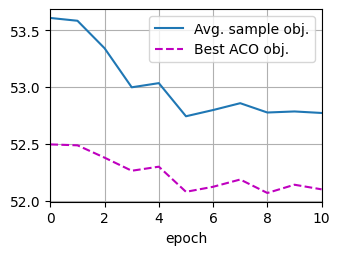

In [4]:
n_node = 500
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

total training duration: 486.52096152305603
epoch -1: (14.762440621852875, 13.56223350763321)
epoch 0: (14.768722414970398, 13.566489517688751)
epoch 1: (14.692757189273834, 13.53030014038086)
epoch 2: (14.501448035240173, 13.42610478401184)
epoch 3: (14.44851416349411, 13.409796953201294)
epoch 4: (14.424829840660095, 13.401500642299652)
epoch 5: (14.377063810825348, 13.359288573265076)
epoch 6: (14.397730529308319, 13.425933003425598)
epoch 7: (14.426755905151367, 13.44795709848404)
epoch 8: (14.377508580684662, 13.400300025939941)
epoch 9: (14.341403305530548, 13.416273295879364)


train/avg_cost,▂▇▂▆▅█▂▆▄▅▁▅▂▇▃▄▃▆▆▅▃▇▅▃▅▁▂▃▃▅▂▆▄▄▃▂▁▃▃▆
train/best_cost,▄▆█▅▆▃▇▅▄▄▅▁▅▄▃▆▃▂▅▁█▅▆▂█▄▇▄▅▅▃▆▄▄▅▄▅▅▁▇
train/epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
train/avg_cost,14.30842
train/best_cost,13.1878
train/epoch,9


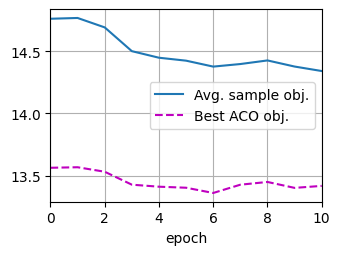

In [ ]:

n_node = 100
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

total training duration: 881.0100266933441
epoch -1: (99.81401491165161, 98.71514463424683)
epoch 0: (99.6786241531372, 98.73306703567505)
epoch 1: (99.53896570205688, 98.60621404647827)
epoch 2: (99.42467308044434, 98.54821491241455)
epoch 3: (99.19452714920044, 98.36873006820679)
epoch 4: (99.15442419052124, 98.31507444381714)
epoch 5: (98.86594247817993, 98.05460023880005)
epoch 6: (98.80945873260498, 98.04836082458496)
epoch 7: (98.46130418777466, 97.77082920074463)
epoch 8: (98.46782350540161, 97.78382301330566)
epoch 9: (98.50065994262695, 97.78852558135986)


train/avg_cost,▇█▄▅▆▇█▂▄▄▄▆▆▇▇▄▇▁▄▃▆▆▅▆▂▄▆▇▄▄▂▆▃▇▄▆▅▃▄▅
train/best_cost,▅▇▆▅▄▅▆▄▆▂▆▅▃▅▂▃█▄▃▃▇▅▄▇▅▄▁▅▇▅▂▄▆▁▆▅▃▆▄▅
train/epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇███
train/avg_cost,98.27627
train/best_cost,97.6868
train/epoch,9


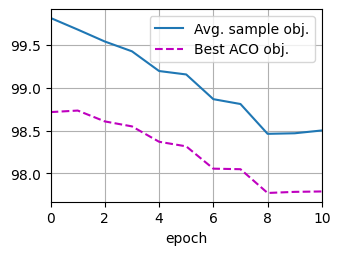

In [5]:
n_node = 1000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)

In [6]:
# n_nod  , k_sparse, n_ants, steps_per_epoch, epochs, True)

KeyboardInterrupt: 

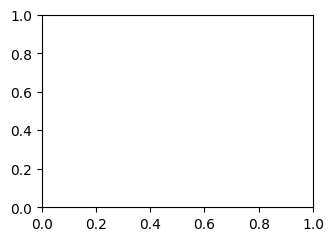

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7f20b631b6f0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7f20b5f55d50, execution_count=7 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 7f20b5f55750, raw_cell="n_node = 5000
n_ants = 100
k_sparse = 32
steps_per.." transformed_cell="n_node = 5000
n_ants = 100
k_sparse = 32
steps_per.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/home/shora/Research/old/NGFACO/cvrp/train.ipynb#X26sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [7]:
n_node = 5000
n_ants = 100
k_sparse = 32
steps_per_epoch = 32
epochs = 10
train(n_node, k_sparse, n_ants, steps_per_epoch, epochs, True)